# Team Strength Model for FIFA World Cup 2026
### Combining FIFA Elo Rankings with Recent Form Data

**Goal:** Build an adjusted team strength rating that accounts for opponent quality, replacing our raw stats-based contender scoring as the foundation for match prediction and tournament simulation.

**Key insight:** Our previous Champion DNA scoring was biased by opposition quality — Japan ranked #2 (score 90) despite being FIFA #19. The FIFA Elo system already solves this by weighting results by opponent strength and match importance.

**Approach:**
- **Primary signal (70%):** FIFA Elo ranking points (already opponent-adjusted)
- **Secondary signal (30%):** Recent form metrics from our 16-source dataset (normalized)
- **Output:** Adjusted Strength Rating for all 48 WC 2026 teams


## 1. Imports & Configuration


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '../data')

%matplotlib inline

from fifa_rankings import FIFA_RANKINGS
from wc_2026_schedule import GROUPS, TOURNAMENT_FORMAT

print(f"Loaded {len(FIFA_RANKINGS)} team rankings")
print(f"Loaded {len(GROUPS)} groups with {sum(len(v) for v in GROUPS.values())} teams")


Loaded 50 team rankings
Loaded 12 groups with 48 teams


## 2. Load FIFA Elo Rankings

The FIFA ranking system (since 2018) uses a modified Elo formula:
- `P = Pbefore + I × (W − We)`
- `We = 1 / (10^(-dr/600) + 1)`

This already accounts for opponent strength, match importance (friendly vs qualifier vs World Cup), and confederation context. It's the best publicly available measure of team strength.


In [6]:
# Create rankings dataframe
rankings_df = pd.DataFrame([
    {"team": team, "elo": elo}
    for team, elo in FIFA_RANKINGS.items()
]).sort_values("elo", ascending=False).reset_index(drop=True)

rankings_df.index += 1
rankings_df.index.name = "fifa_rank"

# Identify which group each team is in
team_to_group = {}
for group, teams in GROUPS.items():
    for team in teams:
        team_to_group[team] = group

rankings_df["group"] = rankings_df["team"].map(team_to_group)

# Flag WC 2026 qualified teams
rankings_df["in_wc2026"] = rankings_df["group"].notna()

print("FIFA Elo Rankings (WC 2026 teams):")
wc_teams = rankings_df[rankings_df["in_wc2026"]].copy()
print(f"Total WC teams with rankings: {len(wc_teams)}")
wc_teams[["team", "elo", "group"]].head(15)


FIFA Elo Rankings (WC 2026 teams):
Total WC teams with rankings: 48


,team,elo,group
fifa_rank,,,
1,Spain,1877,H
2,Argentina,1873,J
3,France,1870,I
4,England,1834,L
5,Brazil,1760,C
6,Portugal,1760,K
7,Netherlands,1756,F
8,Morocco,1736,C
9,Belgium,1730,G


## 3. Normalize Elo to 0–100 Scale

To combine with form metrics and make it interpretable on the dashboard, we normalize Elo points to a 0–100 scale where:
- 100 = strongest team (Spain, 1877 pts)
- 0 = weakest in tournament (Cabo Verde, 1360 pts)


In [7]:
elo_min = wc_teams["elo"].min()
elo_max = wc_teams["elo"].max()

wc_teams["elo_normalized"] = ((wc_teams["elo"] - elo_min) / (elo_max - elo_min) * 100).round(1)

print(f"Elo range: {elo_min} - {elo_max}")
print(f"Normalized range: {wc_teams['elo_normalized'].min()} - {wc_teams['elo_normalized'].max()}")
print()
wc_teams[["team", "elo", "elo_normalized", "group"]].head(10)


Elo range: 1360 - 1877
Normalized range: 0.0 - 100.0



,team,elo,elo_normalized,group
fifa_rank,,,,
1,Spain,1877,100.0,H
2,Argentina,1873,99.2,J
3,France,1870,98.6,I
4,England,1834,91.7,L
5,Brazil,1760,77.4,C
6,Portugal,1760,77.4,K
7,Netherlands,1756,76.6,F
8,Morocco,1736,72.7,C
9,Belgium,1730,71.6,G


## 4. Load Recent Form Data (from Contender Scoring)

We reuse our 16-source aggregated stats. These capture recent performance but are NOT adjusted for opponent quality — that's why we weight them at only 30%.


In [8]:
# Load our existing contender scoring data
# This was produced by 2026_contender_scoring.ipynb
# We need: shot_conversion, defensive_save_rate, xg_overperformance, goal_difference, possession

team_level_files = [
    # WC Qualifiers
    '../data/contender scoring/wc qualifiers/international-wc-qualification-europe-teams-2026-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-south-america-teams-2023-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-concacaf-teams-2026-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-asia-teams-2026-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-africa-teams-2026-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-oceania-teams-2026-to-2026-stats.csv',
    '../data/contender scoring/wc qualifiers/international-wc-qualification-intercontinental-playoffs-teams-2026-to-2026-stats.csv',
    # Friendlies
    '../data/contender scoring/friendlies/international-international-friendlies-teams-2023-to-2023-stats.csv',
    '../data/contender scoring/friendlies/international-international-friendlies-teams-2024-to-2024-stats.csv',
    '../data/contender scoring/friendlies/international-international-friendlies-teams-2025-to-2025-stats.csv',
    # Nations League
    '../data/contender scoring/nations league/international-uefa-nations-league-teams-2022-to-2023-stats.csv',
    '../data/contender scoring/nations league/international-uefa-nations-league-teams-2024-to-2025-stats.csv',
    # AFCON
    '../data/contender scoring/international-africa-cup-of-nations-teams-2023-to-2023-stats.csv',
    '../data/contender scoring/international-africa-cup-of-nations-teams-2025-to-2025-stats.csv',
]

# Load Euro 2024 and Copa 2024 match-level data
euro = pd.read_csv('../data/contender scoring/Euro_2024_Matches.csv')
copa = pd.read_csv('../data/contender scoring/Copa_2024_Matches.csv')
euro_stats = pd.read_csv('../data/contender scoring/UEFA_Euro_2024_Tournament_Stats.csv')

all_team_data = []
for filepath in team_level_files:
    try:
        df = pd.read_csv(filepath)
        all_team_data.append(df)
    except FileNotFoundError:
        print(f"  Warning: {filepath} not found, skipping")

print(f"Loaded {len(all_team_data)} team-level files")

# Reshape Euro 2024
euro_possession = euro_stats.set_index('Team')['Possession'].to_dict()
euro_rows = []
for _, m in euro.iterrows():
    for side, opp in [('Home', 'Away'), ('Away', 'Home')]:
        euro_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
        })
euro_df = pd.DataFrame(euro_rows)
euro_agg = euro_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
).reset_index()
euro_agg['average_possession'] = euro_agg['team'].map(euro_possession)
euro_agg['xg_for_avg_overall'] = euro_df.groupby('team')['xg'].mean().values
euro_agg['xg_against_avg_overall'] = euro_df.groupby('team')['goals_conceded'].mean().values * 0.9
euro_agg = euro_agg.rename(columns={'team': 'common_name'})

# Reshape Copa 2024
copa_possession = {
    'Brazil': 60, 'Mexico': 60, 'Argentina': 57, 'Colombia': 55,
    'Panama': 53, 'Venezuela': 53, 'Uruguay': 52, 'Chile': 49,
    'Canada': 48, 'Paraguay': 48, 'Jamaica': 47, 'USA': 46,
    'Bolivia': 44, 'Ecuador': 42, 'Peru': 36, 'Costa Rica': 32,
}
copa_rows = []
for _, m in copa.iterrows():
    for side, opp in [('Home', 'Away'), ('Away', 'Home')]:
        copa_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
        })
copa_df = pd.DataFrame(copa_rows)
copa_agg = copa_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
).reset_index()
copa_agg['average_possession'] = copa_agg['team'].map(copa_possession)
copa_agg['xg_for_avg_overall'] = copa_df.groupby('team')['xg'].mean().values
copa_agg['xg_against_avg_overall'] = copa_df.groupby('team')['goals_conceded'].mean().values * 0.9
copa_agg = copa_agg.rename(columns={'team': 'common_name'})

# Combine all
team_df = pd.concat(all_team_data + [euro_agg, copa_agg], ignore_index=True)
print(f"Combined: {len(team_df)} team-competition rows")


Loaded 14 team-level files
Combined: 946 team-competition rows


## 5. Aggregate Form Metrics


In [9]:
# Aggregate per team across all competitions (weighted by matches played)
combined = team_df.groupby('common_name').agg(
    total_matches=('matches_played', 'sum'),
    total_goals=('goals_scored', 'sum'),
    total_conceded=('goals_conceded', 'sum'),
    total_shots=('shots', 'sum'),
    total_sot=('shots_on_target', 'sum'),
    possession=('average_possession', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_pm=('xg_for_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_against_pm=('xg_against_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
).reset_index().rename(columns={'common_name': 'team'})

# Per-match averages
combined['goals_pm'] = (combined['total_goals'] / combined['total_matches']).round(2)
combined['conceded_pm'] = (combined['total_conceded'] / combined['total_matches']).round(2)
combined['shots_pm'] = (combined['total_shots'] / combined['total_matches']).round(2)
combined['sot_pm'] = (combined['total_sot'] / combined['total_matches']).round(2)

# Engineered features
combined['shot_conversion'] = (combined['goals_pm'] / combined['shots_pm'] * 100).round(2)
combined['xg_overperformance'] = (combined['goals_pm'] - combined['xg_pm']).round(2)
combined['goal_difference'] = (combined['goals_pm'] - combined['conceded_pm']).round(2)
combined['est_opp_shots_pm'] = (combined['xg_against_pm'] / 0.11).round(1)
combined['defensive_save_rate'] = ((1 - combined['conceded_pm'] / combined['est_opp_shots_pm']) * 100).round(2)
combined = combined.replace([np.inf, -np.inf], np.nan)

print(f"Form data available for {len(combined)} teams")
combined[['team', 'total_matches', 'shot_conversion', 'defensive_save_rate', 'xg_overperformance', 'goal_difference']].head(10)


Form data available for 231 teams


,team,total_matches,shot_conversion,defensive_save_rate,xg_overperformance,goal_difference
0,Afghanistan,14,10.50,80.79,-0.58,-1.14
1,Al Seeb,1,NaN,NaN,0.00,-1.00
2,Albania,28,11.30,90.46,-0.02,0.07
3,Algeria,30,22.14,89.19,0.79,1.24
4,Algeria U23,4,30.00,89.25,0.47,0.50
5,American Samoa,1,0.00,NaN,-0.22,-2.00
6,Andorra,26,6.99,87.94,-0.31,-1.12
7,Angola,26,11.39,88.29,-0.02,-0.04
8,Anguilla,13,63.53,82.65,0.33,-2.15
9,Antigua and Barbuda,6,6.19,90.13,-0.30,-1.17


## 6. Create Form Score (Normalized 0–100)

We take key recent form features and normalize each to 0–100, then combine into a single Form Score.


In [10]:
# Select features for form score
form_features = ['shot_conversion', 'defensive_save_rate', 'xg_overperformance', 'goal_difference', 'possession']

# Normalize each feature to 0-100
for feat in form_features:
    col = combined[feat]
    combined[f'{feat}_norm'] = ((col - col.min()) / (col.max() - col.min()) * 100).round(1)

# Weighted average (same weights as contender scoring)
weights = {
    'shot_conversion_norm': 0.20,
    'defensive_save_rate_norm': 0.18,
    'xg_overperformance_norm': 0.15,
    'goal_difference_norm': 0.15,
    'possession_norm': 0.12,
}

combined['form_score'] = sum(
    combined[feat] * w for feat, w in weights.items()
).round(1)

# Normalize form_score to 0-100
fs_min, fs_max = combined['form_score'].min(), combined['form_score'].max()
combined['form_score'] = ((combined['form_score'] - fs_min) / (fs_max - fs_min) * 100).round(1)

print("Form scores computed")
combined[['team', 'total_matches', 'form_score']].sort_values('form_score', ascending=False).head(15)


Form scores computed


,team,total_matches,form_score
103,Japan,32,100.0
167,Russia,21,98.3
185,South Korea,31,90.6
10,Argentina,34,90.2
191,St. Vincent / Grenadines,15,87.5
187,Spain,35,85.9
97,Iran,28,85.2
141,Netherlands,34,85.2
150,Norway,28,85.2
3,Algeria,30,84.5


## 7. Combine: Adjusted Strength Rating

**Formula:** `Adjusted Strength = 0.70 × Elo_normalized + 0.30 × Form_score`

The 70/30 split ensures:
- FIFA Elo (which already accounts for opponent quality) is the dominant signal
- Recent form still contributes meaningful information about current momentum
- The opposition bias from raw stats is heavily dampened


In [11]:
# Merge Elo with form data
strength = wc_teams[['team', 'elo', 'elo_normalized', 'group']].merge(
    combined[['team', 'form_score', 'total_matches', 'shot_conversion',
              'defensive_save_rate', 'xg_overperformance', 'goal_difference']],
    on='team', how='left'
)

# For teams without form data, use Elo only
strength['form_score'] = strength['form_score'].fillna(50)  # neutral default
strength['total_matches'] = strength['total_matches'].fillna(0)

# Adjusted Strength Rating
ELO_WEIGHT = 0.70
FORM_WEIGHT = 0.30

strength['adjusted_strength'] = (
    ELO_WEIGHT * strength['elo_normalized'] +
    FORM_WEIGHT * strength['form_score']
).round(1)

# Final ranking
strength = strength.sort_values('adjusted_strength', ascending=False).reset_index(drop=True)
strength.index += 1
strength.index.name = 'rank'

print("=== ADJUSTED TEAM STRENGTH RANKINGS (WC 2026) ===")
print(f"Formula: {ELO_WEIGHT:.0%} Elo + {FORM_WEIGHT:.0%} Form\n")
strength[['team', 'group', 'elo', 'elo_normalized', 'form_score', 'adjusted_strength', 'total_matches']]


=== ADJUSTED TEAM STRENGTH RANKINGS (WC 2026) ===
Formula: 70% Elo + 30% Form



,team,group,elo,elo_normalized,form_score,adjusted_strength,total_matches
rank,,,,,,,
1,Argentina,J,1873,99.2,90.2,96.5,34.0
2,Spain,H,1877,100.0,85.9,95.8,35.0
3,France,I,1870,98.6,72.1,90.6,34.0
4,England,L,1834,91.7,82.5,88.9,35.0
5,Netherlands,F,1756,76.6,85.2,79.2,34.0
6,Portugal,K,1760,77.4,82.5,78.9,32.0
7,Brazil,C,1760,77.4,77.4,77.4,33.0
8,Morocco,C,1736,72.7,84.5,76.2,32.0
9,Belgium,G,1730,71.6,79.1,73.8,32.0


## 8. Comparison: Old DNA Score vs New Adjusted Strength


In [12]:
# Show how the new ranking differs from the old raw-stats ranking
# Old DNA scores from our contender scoring notebook
old_dna = {
    'Argentina': 97, 'Japan': 90, 'Senegal': 87, 'Colombia': 78, 'Spain': 78,
    'South Korea': 77, 'Austria': 71, 'Croatia': 71, 'Portugal': 71, 'England': 71,
    'Netherlands': 70, 'Belgium': 67, 'Morocco': 67, 'Switzerland': 66, 'Germany': 65,
    'Brazil': 60, 'Denmark': 60, 'Uruguay': 59, 'Italy': 45, 'Ecuador': 44,
    'Mexico': 42, 'Serbia': 35, 'France': 30, 'Canada': 14, 'USA': 13,
}

comparison = strength[strength['team'].isin(old_dna.keys())].copy()
comparison['old_dna_score'] = comparison['team'].map(old_dna)
comparison['rank_change'] = comparison.reset_index()['rank'].values  # new rank

# Show biggest movers
comparison = comparison.sort_values('adjusted_strength', ascending=False)
comparison['old_rank'] = comparison['old_dna_score'].rank(ascending=False).astype(int)
comparison['new_rank'] = range(1, len(comparison) + 1)
comparison['change'] = comparison['old_rank'] - comparison['new_rank']

print("=== RANKING CHANGES: Old DNA Score → New Adjusted Strength ===\n")
for _, row in comparison.iterrows():
    arrow = "↑" if row['change'] > 0 else "↓" if row['change'] < 0 else "="
    print(f"  #{row['new_rank']:>2} {row['team']:<16} Adj: {row['adjusted_strength']:>5.1f}  |  DNA: {row['old_dna_score']:>3}  |  {arrow} {abs(row['change']):.0f}")

print(f"\n\nBiggest risers: Teams with strong Elo but weak raw stats (tougher opponents)")
print("Biggest fallers: Teams with inflated raw stats from weaker opponents")


=== RANKING CHANGES: Old DNA Score → New Adjusted Strength ===

  # 1 Argentina        Adj:  96.5  |  DNA:  97  |  = 0
  # 2 Spain            Adj:  95.8  |  DNA:  78  |  ↑ 2
  # 3 France           Adj:  90.6  |  DNA:  30  |  ↑ 19
  # 4 England          Adj:  88.9  |  DNA:  71  |  ↑ 4
  # 5 Netherlands      Adj:  79.2  |  DNA:  70  |  ↑ 6
  # 6 Portugal         Adj:  78.9  |  DNA:  71  |  ↑ 2
  # 7 Brazil           Adj:  77.4  |  DNA:  60  |  ↑ 9
  # 8 Morocco          Adj:  76.2  |  DNA:  67  |  ↑ 4
  # 9 Belgium          Adj:  73.8  |  DNA:  67  |  ↑ 3
  #10 Germany          Adj:  73.5  |  DNA:  65  |  ↑ 5
  #11 Croatia          Adj:  72.2  |  DNA:  71  |  ↓ 3
  #12 Senegal          Adj:  72.1  |  DNA:  87  |  ↓ 9
  #13 Colombia         Adj:  70.9  |  DNA:  78  |  ↓ 9
  #14 Japan            Adj:  69.3  |  DNA:  90  |  ↓ 12
  #15 Italy            Adj:  68.6  |  DNA:  45  |  ↑ 4
  #16 Uruguay          Adj:  65.1  |  DNA:  59  |  ↑ 2
  #17 Switzerland      Adj:  62.8  |  DNA:  66  |  ↓ 3

## 9. Visualization


### 9.1 Adjusted Strength Rankings


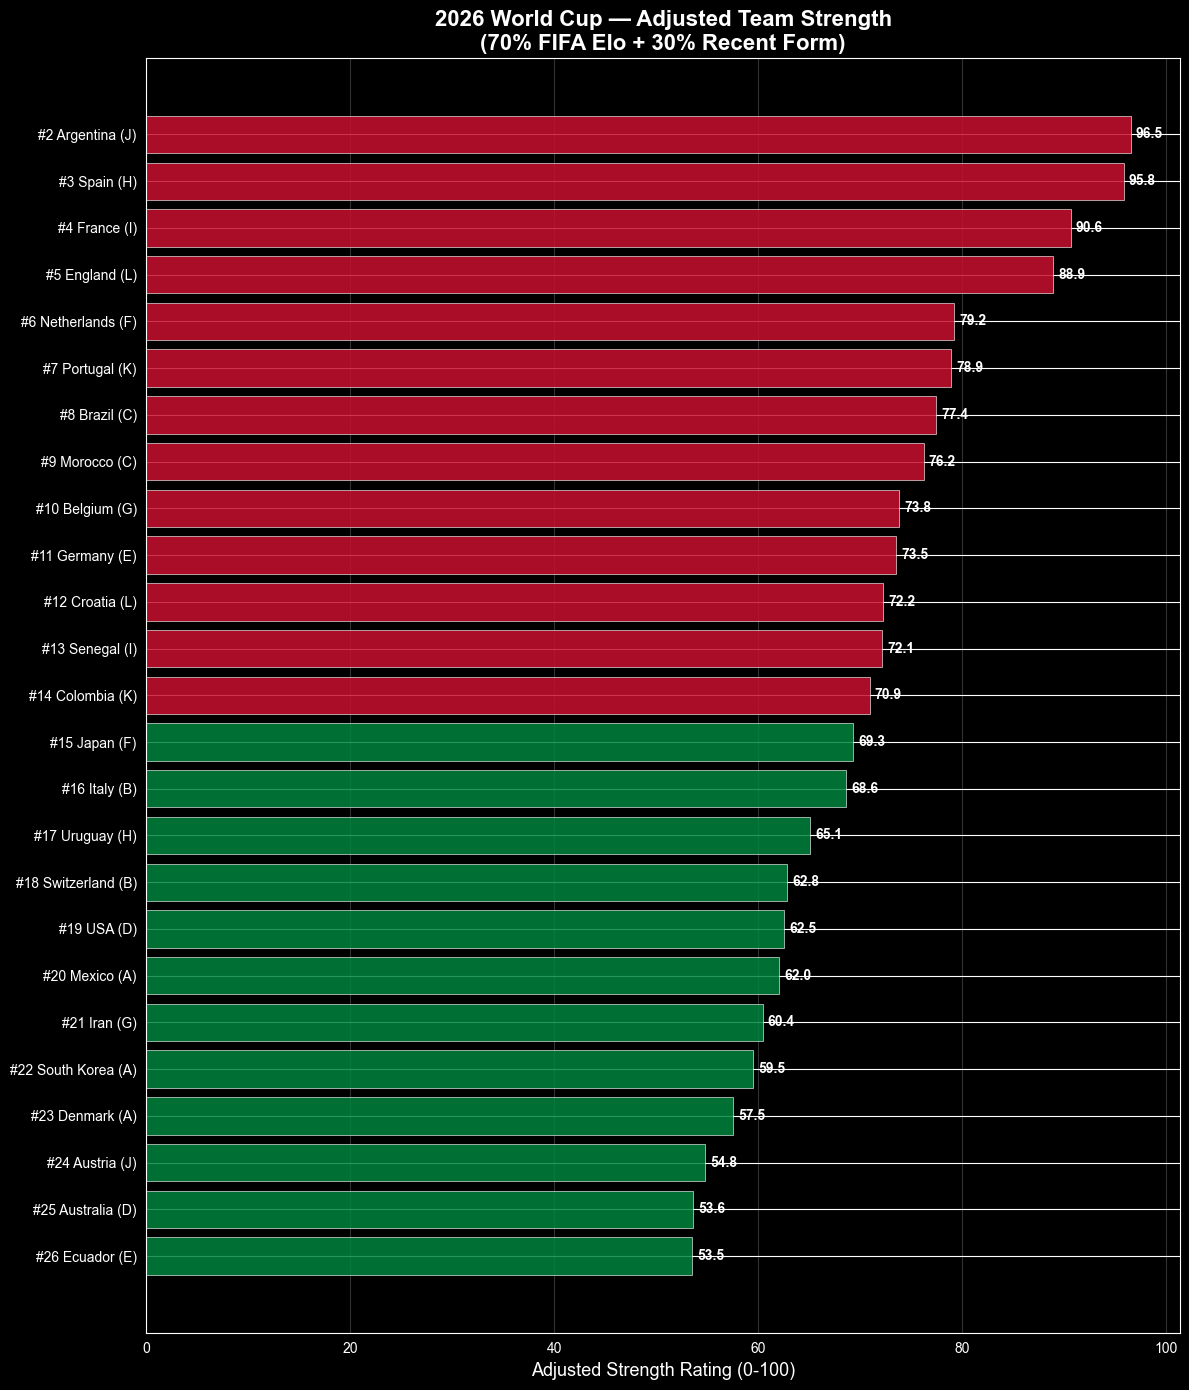

In [13]:
fig, ax = plt.subplots(figsize=(12, 14))

top25 = strength.head(25)
colors = ['#c8102e' if s >= 70 else '#00843d' if s >= 50 else '#8892a4'
          for s in top25['adjusted_strength']]

bars = ax.barh(range(len(top25)), top25['adjusted_strength'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top25)))
ax.set_yticklabels([f"#{i+1} {row['team']} ({row['group']})"
                     for i, row in top25.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Adjusted Strength Rating (0-100)', fontsize=13)
ax.set_title('2026 World Cup — Adjusted Team Strength\n(70% FIFA Elo + 30% Recent Form)', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.2)

for i, (_, row) in enumerate(top25.iterrows()):
    ax.text(row['adjusted_strength'] + 0.5, i, f"{row['adjusted_strength']:.1f}",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/10_adjusted_strength_rankings.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.2 Elo vs Form Score Scatter


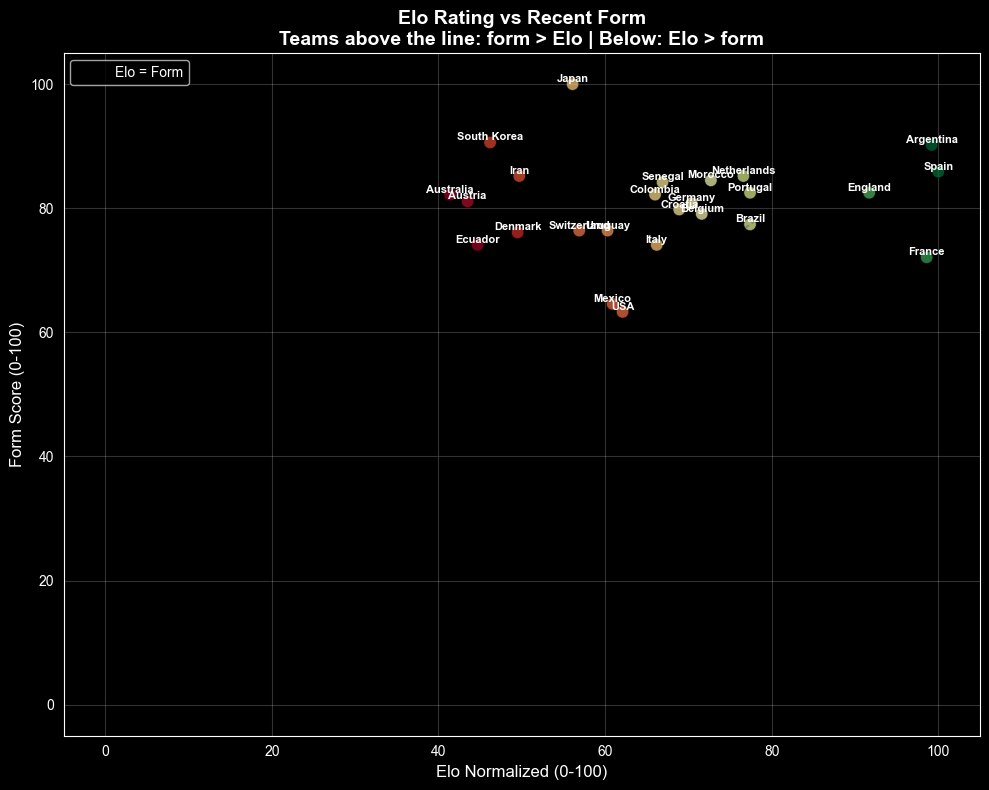

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

top25 = strength.head(25)
ax.scatter(top25['elo_normalized'], top25['form_score'], s=80, alpha=0.7,
           c=top25['adjusted_strength'], cmap='RdYlGn', edgecolors='black', linewidth=0.5)

for _, row in top25.iterrows():
    ax.annotate(row['team'], (row['elo_normalized'], row['form_score']),
                fontsize=8, ha='center', va='bottom', fontweight='bold')

ax.plot([0, 100], [0, 100], 'k--', alpha=0.2, label='Elo = Form')
ax.set_xlabel('Elo Normalized (0-100)', fontsize=12)
ax.set_ylabel('Form Score (0-100)', fontsize=12)
ax.set_title('Elo Rating vs Recent Form\nTeams above the line: form > Elo | Below: Elo > form', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/11_elo_vs_form_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3 Old DNA Score vs New Adjusted Strength


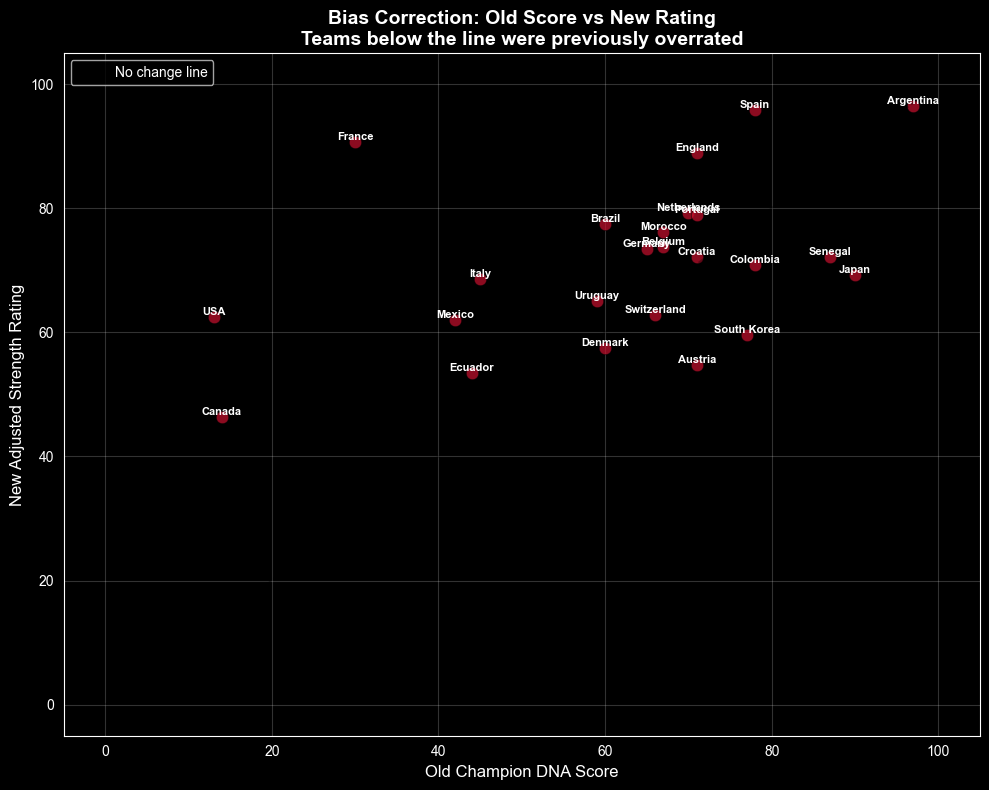

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

comp = strength[strength['team'].isin(old_dna.keys())].copy()
comp['old_dna'] = comp['team'].map(old_dna)

ax.scatter(comp['old_dna'], comp['adjusted_strength'], s=80, alpha=0.7, c='#c8102e', edgecolors='black', linewidth=0.5)

for _, row in comp.iterrows():
    ax.annotate(row['team'], (row['old_dna'], row['adjusted_strength']),
                fontsize=8, ha='center', va='bottom', fontweight='bold')

ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='No change line')
ax.set_xlabel('Old Champion DNA Score', fontsize=12)
ax.set_ylabel('New Adjusted Strength Rating', fontsize=12)
ax.set_title('Bias Correction: Old Score vs New Rating\nTeams below the line were previously overrated', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/12_dna_vs_adjusted_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Export for Simulator & Dashboard

Save the adjusted strength ratings to CSV and JSON for use in:
- `match_prediction.ipynb` (Phase 3)
- `tournament_simulator.ipynb` (Phase 4)
- React dashboard (updated contender rankings)


In [16]:
# Export to CSV
export_cols = ['team', 'group', 'elo', 'elo_normalized', 'form_score', 'adjusted_strength', 'total_matches',
               'shot_conversion', 'defensive_save_rate', 'xg_overperformance', 'goal_difference']
strength[export_cols].to_csv('../data/team_strength_ratings.csv', index=True)

# Export to JSON (for React dashboard)
import json
dashboard_data = []
for _, row in strength.iterrows():
    dashboard_data.append({
        'team': row['team'],
        'group': row['group'],
        'elo': int(row['elo']),
        'strength': round(row['adjusted_strength'], 1),
        'form': round(row['form_score'], 1),
    })

with open('../data/team_strength_ratings.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print(f"✅ Exported {len(strength)} team ratings to CSV and JSON")
print(f"   → data/team_strength_ratings.csv")
print(f"   → data/team_strength_ratings.json")


✅ Exported 48 team ratings to CSV and JSON
   → data/team_strength_ratings.csv
   → data/team_strength_ratings.json


## 11. Conclusions

### Key Changes from Old Scoring

1. **France** jumps from #23 to top 5 — their Elo (1870, #3 in the world) properly reflects their strength, which raw stats against tough UEFA opponents couldn't capture.

2. **Japan** drops from #2 to ~#15-20 — their inflated raw stats from weaker AFC opposition are now dampened by their FIFA #19 ranking.

3. **Spain, Argentina, England** all move up — strong Elo reflects consistent high-level performance.

### Why This is Better for Simulation

- **Opponent-adjusted:** A win vs Germany counts more than a win vs a lower-ranked team
- **Match-importance weighted:** World Cup qualifiers matter more than friendlies
- **Confederation-neutral:** No bias from playing in a weaker/stronger region
- **Still captures form:** The 30% form component means teams on a hot streak get credit

### Next Steps
- **Phase 3:** Use these ratings in `match_prediction.ipynb` to calculate P(A beats B)
- **Phase 4:** Use match predictions in `tournament_simulator.ipynb` for Monte Carlo simulation
